<a href="https://colab.research.google.com/github/Charan-BE21B010/My-Projects/blob/my-projects/Electricity_Forecasting_demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview
- You will perform electricity demand forecasting using the data provided in a Google Colaboratory notebook.
- For instructions on using Google Colaboratory, please refer to this [link](https://colab.research.google.com/?hl=ja#scrollTo=Wf5KrEb6vrkR).
- The provided data consists of two types:
  - electricity_demand.csv: Electricity demand values within the Kansai Electric Power (JP) jurisdiction.
  - {location}.csv: Actual weather data for specific locations.

## Rules
- The forecasting target period is January 1, 2023, 00:00:00 – December 31, 2023, 23:00:00.
- Electricity demand values can only be used up until 23:00:00 of the day before the target date.
- There are no restrictions on forecasting methods (choose methods available in the free-tier plan).
- The use of additional data from libraries such as jpholiday is permitted.
  - If additional libraries are used, include the installation command in the notebook (e.g., ! pip install pandas).

## Required Deliverables
Use both code and Markdown as needed to provide the following information:

- Model Development for Electricity Demand Forecasting
  - Justify the choice of method and, if applicable, describe any hypotheses regarding feature engineering.
- Evaluation of Forecasting Performance Using Actual Data
  - Specify and justify the selected evaluation metrics.
- Error Analysis and Model Challenges
- Discuss issues identified through error analysis.
- Hypotheses for Accuracy Improvement
  - Provide potential strategies for enhancing model performance.
- Expected Benefits of Model Deployment
  - Explain the potential impact and advantages of implementing the model.

## Submission
- Once coding and execution are completed in Google Colaboratory, download the executed notebook and submit it.
- Submit your notebook through the designated agent.


Load datasets

In [39]:
import pandas as pd
demand = pd.read_csv("/content/demand.csv")
hikone = pd.read_csv("/content/hikone.csv")

Convert datetime column

In [40]:
demand['datetime'] = pd.to_datetime(demand['datetime'], errors='coerce')
hikone['datetime'] = pd.to_datetime(hikone['datetime'], errors='coerce')

Merge datasets on datetime

In [24]:
data = pd.merge(demand, hikone, on='datetime', how='inner')

Filter for the year 2023

In [41]:
start_date = '2023-01-01 00:00:00'
end_date = '2023-12-31 23:00:00'
merged_df = data[(data['datetime'] >= start_date) & (data['datetime'] <= end_date)]

Define features and target

In [43]:
features = ['temperature', 'humidity', 'wind_speed', 'precipitation']
target = 'actual_performance(10000 kW)'

In [44]:
X = merged_df[features]
y = merged_df[target]

Train-test split

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model selection and training

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Predictions

In [31]:
y_pred = model.predict(X_test)

Evaluation metrics

In [33]:
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) # If R² is low, consider feature selection techniques or alternative models like XGBoost for better performance.

Display results

In [35]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 235.86750736306084
MSE: 96655.89813697792
RMSE: 310.89531700715264
R2 Score: 0.03641422565667085


Error Analysis

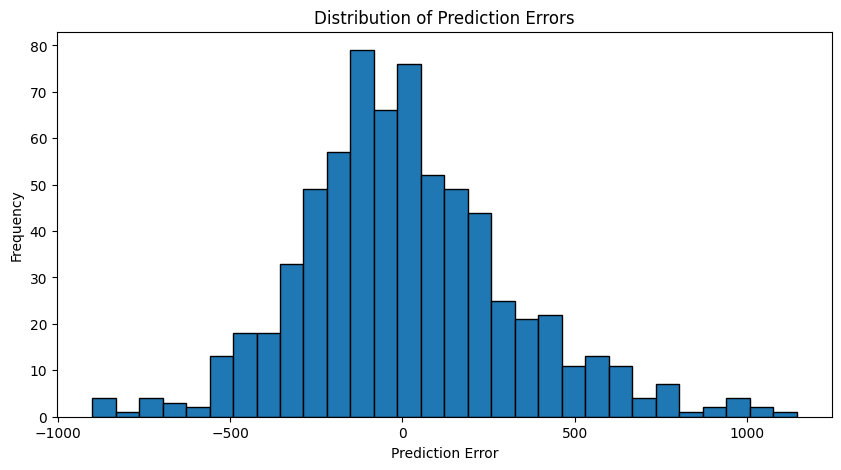

In [36]:
import matplotlib.pyplot as plt
errors = y_test - y_pred #analyzing the errors further by checking if they correlate with specific time periods or weather conditions
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black') #To  overlay a normal distribution curve to better visualize the error spread.
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()